# Ali Abdullah Ahmad
# CWID - 20031246
# CS513-A

## Problem 2 – Random Forest (15 points)
Load the “hepatitis_A.csv” dataset, from the Raw_data module in CANVAS, into Python/R
(Excel file containing another variation of the hepatitis dataset). This is a dataset used for
predicting “patient mortality”. Delete any row with missing values and construct a Random
Forest model to classify “patient mortality” based only on the “SEX”,”Age_Quartile”,
“STEROID”, “FATIGUE” and “MALAISE” attributes. Show feature importance
What is the accuracy of your model? Is this a good model? Why or why not.
(30% test, 70% training)

In [7]:
# Import required libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Load the dataset
file_path = 'D:/Stevens GIT/Stevens_IT-MS_in_CS/SPRING_25/CS513_Knowledge_Discovery&Data_Mining/Final/hepatitis_A.csv'  # Update path as needed
df = pd.read_csv(file_path)
df.head()

,Class,AGE,SEX,STEROID,ANTIVIRALS,FATIGUE,MALAISE,ANOREXIA,LIVER_BIG,LIVER_FIRM,SPLEEN_PALPABLE,SPIDERS,ASCITES,VARICES,BILIRUBIN,ALK_PHOSPHATE,SGOT,ALBUMIN,HISTOLOGY,Age_Quartile
0,2,30,2,1.0,2,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0,85.0,18.0,4.0,1,Q1
1,2,50,1,1.0,2,1.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,0.9,135.0,42.0,3.5,1,Q3
2,2,78,1,2.0,2,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.7,96.0,32.0,4.0,1,Q4
3,2,31,1,NaN,1,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.7,46.0,52.0,4.0,1,Q1
4,2,34,1,2.0,2,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,NaN,200.0,4.0,1,Q2


Random Forest Model Accuracy: 79.41%

Classification Report:
               precision    recall  f1-score   support

           1       0.14      0.50      0.22         2
           2       0.96      0.81      0.88        32

    accuracy                           0.79        34
   macro avg       0.55      0.66      0.55        34
weighted avg       0.91      0.79      0.84        34



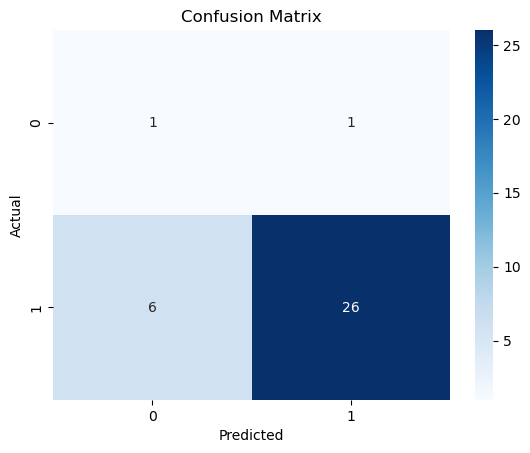

C:\Users\abdul\AppData\Local\Temp\ipykernel_7448\1010893453.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')


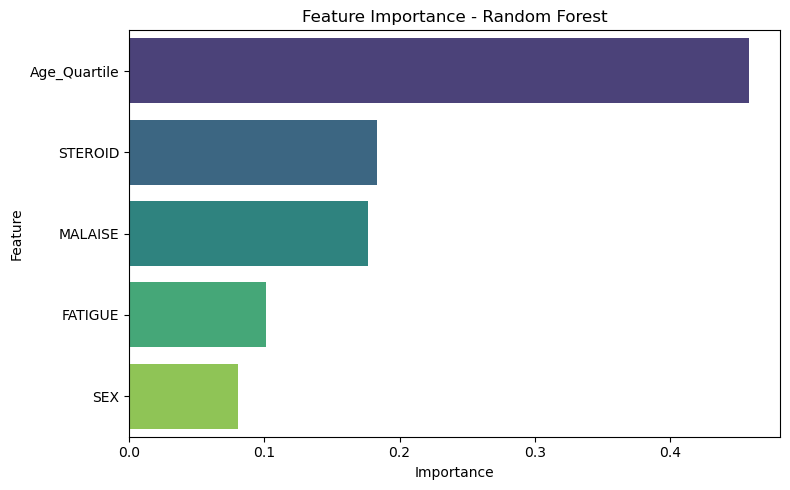


Conclusion:
The model achieved an accuracy of 79.41%.


In [9]:
# Step 1: Drop rows with missing values
df_clean = df.dropna()

# Step 2: Select relevant features and target
features = ['SEX', 'Age_Quartile', 'STEROID', 'FATIGUE', 'MALAISE']
target = 'Class'
df_model = df_clean[features + [target]].copy()

# Step 3: Encode categorical variables
le_age = LabelEncoder()
df_model['Age_Quartile'] = le_age.fit_transform(df_model['Age_Quartile'])


# Step 4: Split data into training and testing sets (70/30)
X = df_model[features]
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 5: Train Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Step 6: Make predictions and evaluate the model
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Model Accuracy: {accuracy * 100:.2f}%")

# Optional: Show classification report and confusion matrix
print("\nClassification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Step 7: Feature importance
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Summary
print("\nConclusion:")
print(f"The model achieved an accuracy of {accuracy * 100:.2f}%.")

This is not a good model for predicting patient mortality in a clinical context.


While the overall accuracy of 79.41% looks strong, the model fails to reliably predict deaths (class 1), which is the most critical outcome. In healthcare, misclassifying high-risk patients as low-risk can have serious consequences. A good model must balance performance across all classes, especially for rare but important outcomes.